<center><img src='https://drive.google.com/uc?id=1-AXpfjw6eCpFvJRlbV5GGXnzCmin6vmL' ></center>

In [1]:
#!pip install tensorflow

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import random
import os
import glob
import tensorflow as tf
from tensorflow import keras # this allows <keras.> instead of <tf.keras.>
from tensorflow.keras import layers # this allows <layers.> instead of <tf.keras.layers.>
tf.keras.utils.set_random_seed(111) # set random seed

# To supress any warnings during the flow
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 14})

In [2]:
from google.colab import drive
drive.mount('/content/gdrive/',force_remount=True)

Mounted at /content/gdrive/


In [3]:
!gdown 11LQILlalZGi_skLIipnpTyh-At77B_j6

Downloading...
From (original): https://drive.google.com/uc?id=11LQILlalZGi_skLIipnpTyh-At77B_j6
From (redirected): https://drive.google.com/uc?id=11LQILlalZGi_skLIipnpTyh-At77B_j6&confirm=t&uuid=99575b05-8414-41cc-9284-7a9755544fad
To: /content/New_landmark_images.zip
100% 112M/112M [00:00<00:00, 153MB/s]


In [4]:
!unzip New_landmark_images.zip

Archive:  New_landmark_images.zip
   creating: New_landmark_images/
   creating: New_landmark_images/train/
   creating: New_landmark_images/train/01.Niagara_Falls/
  inflating: New_landmark_images/train/01.Niagara_Falls/176bf33159dd4780.jpg  
  inflating: New_landmark_images/train/01.Niagara_Falls/43e7e6b715dea27a.jpg  
  inflating: New_landmark_images/train/01.Niagara_Falls/4a18c9d51c84df27.jpg  
  inflating: New_landmark_images/train/01.Niagara_Falls/032a10a9b60eae53.jpg  
  inflating: New_landmark_images/train/01.Niagara_Falls/519776646d035f06.jpg  
  inflating: New_landmark_images/train/01.Niagara_Falls/6a6cd26155db4327.jpg  
  inflating: New_landmark_images/train/01.Niagara_Falls/7a1ddf7a6ae3436d.jpg  
  inflating: New_landmark_images/train/01.Niagara_Falls/7398dbeba39b5fb7.jpg  
  inflating: New_landmark_images/train/01.Niagara_Falls/54be916f53092ef8.jpg  
  inflating: New_landmark_images/train/01.Niagara_Falls/292419d3147c4a34.jpg  
  inflating: New_landmark_images/train/01.Nia

In [5]:
train_data = tf.keras.utils.image_dataset_from_directory("New_landmark_images/train/",shuffle =True, seed=123,image_size=(227, 227),batch_size=32)
val_data   = tf.keras.utils.image_dataset_from_directory("New_landmark_images/validation/",shuffle =False, seed=123,image_size=(227, 227),batch_size=32)
test_data  = tf.keras.utils.image_dataset_from_directory("New_landmark_images/test/",shuffle =False, seed=123,image_size=(227, 227),batch_size=32)

data_preprocess = tf.keras.Sequential(
    name="data_preprocess",
    layers=[ layers.Rescaling(1.0/255),]
)

# Perform Data Processing on the train, val, test dataset
train_ds = train_data.map(lambda x, y: (data_preprocess(x), y))
val_ds = val_data.map(lambda x, y: (data_preprocess(x), y))
test_ds = test_data.map(lambda x, y: (data_preprocess(x), y))

Found 737 files belonging to 10 classes.
Found 155 files belonging to 10 classes.
Found 43 files belonging to 10 classes.


In [6]:
class_dirs = os.listdir("New_landmark_images/train/") # list all directories inside "train" folder
image_dict = {} # dict to store image array(key) for every class(value)
count_dict = {} # dict to store count of files(key) for every class(value)
# iterate over all class_dirs
for cls in class_dirs:
    # get list of all paths inside the subdirectory
    file_paths = glob.glob(f'New_landmark_images/train/{cls}/*')
    # count number of files in each class and add it to count_dict
    count_dict[cls] = len(file_paths)
    # select random item from list of image paths
    image_path = random.choice(file_paths)
    # load image using keras utility function and save it in image_dict
    image_dict[cls] = tf.keras.utils.load_img(image_path)

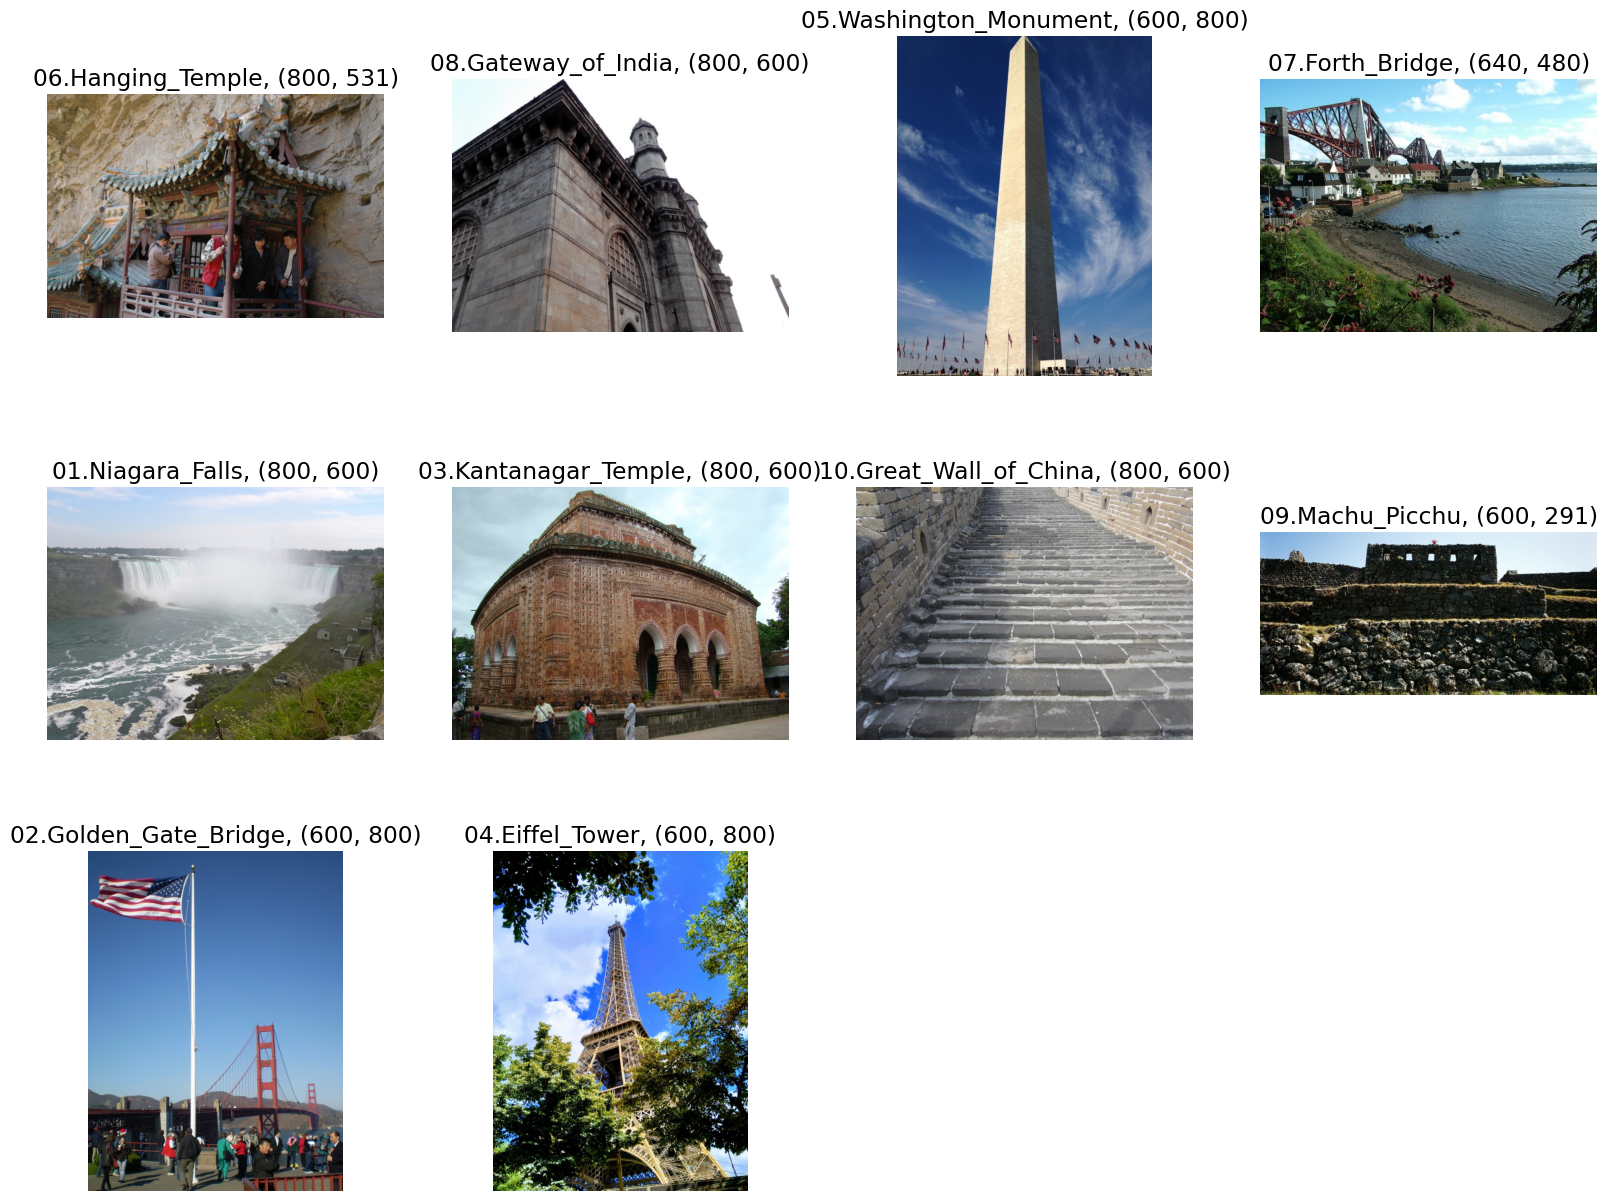

In [7]:
## Viz Random Sample from each class

plt.figure(figsize=(20, 15))
# iterate over dictionary items (class label, image array)
for i, (cls,img) in enumerate(image_dict.items()):
    # create a subplot axis
    ax = plt.subplot(3, 4, i + 1)
    # plot each image
    plt.imshow(img)
    # set "class name" along with "image size" as title
    plt.title(f'{cls}, {img.size}')
    plt.axis("off")

Count of training samples per class:
                     class  count
0       06.Hanging_Temple     70
1     08.Gateway_of_India     87
2  05.Washington_Monument     83
3         07.Forth_Bridge     82
4        01.Niagara_Falls     66
5    03.Kantanagar_Temple     88
6  10.Great_Wall_of_China     72
7         09.Machu_Picchu     55
8   02.Golden_Gate_Bridge     70
9         04.Eiffel_Tower     64


<Axes: title={'center': 'Training Data Count per class'}, xlabel='class'>

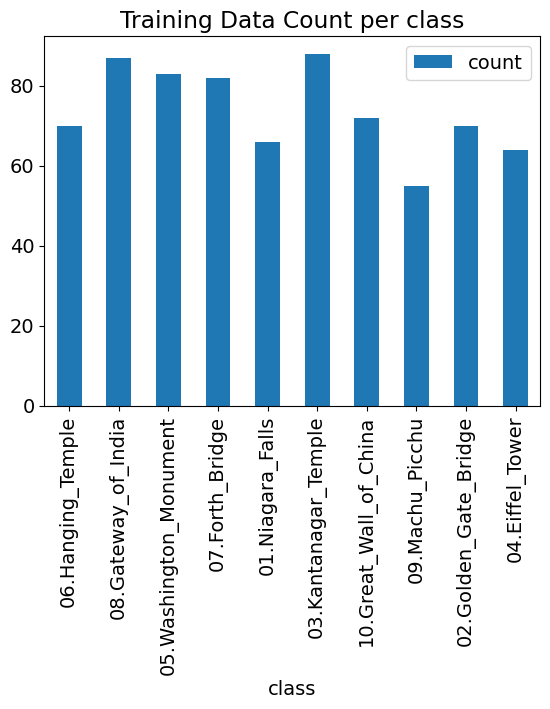

In [8]:
## Let's now Plot the Data Distribution of Training Data across Classes
df_count_train = pd.DataFrame({
    "class": count_dict.keys(),     # keys of count_dict are class labels
    "count": count_dict.values(),   # value of count_dict contain counts of each class
})
print("Count of training samples per class:\n", df_count_train)

# draw a bar plot using pandas in-built plotting function
df_count_train.plot.bar(x='class', y='count', title="Training Data Count per class")

| Model Name | Number of params | Top 1 Acc | Top 5 Acc
| --- | --- | --- | --- |
| Alexnet | 60M | 63.3 | 84.6
| VGG16 | 138M | 74.4| 91.9
| VGG19 | 144M | 74.5| 92.0

In [9]:
#Data Processing

BATCH_SIZE = 128
tf.random.set_seed(10)
np.random.seed(10)

train_ds = tf.keras.utils.image_dataset_from_directory("New_landmark_images/train/",shuffle =True, seed=123,image_size=(224, 224),batch_size=BATCH_SIZE)

val_ds   = tf.keras.utils.image_dataset_from_directory("New_landmark_images/validation/",shuffle =False, seed=123,image_size=(224, 224),batch_size=BATCH_SIZE)

test_ds = tf.keras.utils.image_dataset_from_directory("New_landmark_images/test/",shuffle =False, seed=123,image_size=(224, 224),batch_size=BATCH_SIZE)

data_preprocess = tf.keras.Sequential(
    name="data_preprocess",
    layers=[ layers.Rescaling(1.0/255),]
)

Found 737 files belonging to 10 classes.
Found 155 files belonging to 10 classes.
Found 43 files belonging to 10 classes.


In [10]:
# Perform Data Processing on the train, val, test dataset
train_ds = train_ds.map(lambda x, y: (data_preprocess(x), y))
val_ds = val_ds.map(lambda x, y: (data_preprocess(x), y))
test_ds = test_ds.map(lambda x, y: (data_preprocess(x), y))

In [11]:
lenet_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(6, kernel_size=(5,5),
                        activation= 'sigmoid'),
    tf.keras.layers.AveragePooling2D(pool_size=(2,2), strides= (2,2)),
    tf.keras.layers.Conv2D(16, kernel_size=(5,5),
                        activation= 'sigmoid'),
    tf.keras.layers.AveragePooling2D(pool_size=(2,2), strides= (2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(120, activation= 'sigmoid'),
    tf.keras.layers.Dense(84, activation= 'sigmoid'),
    tf.keras.layers.Dense(10, activation= 'softmax'),

])

In [12]:
lenet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# VGG 16 Model
# If the commented Conv2D layer is uncommented then it becomes VGG 19
# FC layers are commented so that faster training occur
vgg16_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape = (224 ,224, 3)),
        tf.keras.layers.Conv2D(64, kernel_size=(3,3), padding= 'same',
                        activation= 'relu'),
        tf.keras.layers.Conv2D(64, kernel_size=(3,3), padding= 'same',
                        activation= 'relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides= (2,2)),

        tf.keras.layers.Conv2D(128, kernel_size=(3,3), padding= 'same',
                        activation= 'relu'),
        tf.keras.layers.Conv2D(128, kernel_size=(3,3), padding= 'same',
                        activation= 'relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides= (2,2)),

        tf.keras.layers.Conv2D(256, kernel_size=(3,3), padding= 'same',
                        activation= 'relu'),
        tf.keras.layers.Conv2D(256, kernel_size=(3,3), padding= 'same',
                        activation= 'relu'),
        tf.keras.layers.Conv2D(256, kernel_size=(3,3), padding= 'same',
                        activation= 'relu'),
        #tf.keras.layers.Conv2D(256, kernel_size=(3,3), padding= 'same',
        #                activation= 'relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides= (2,2)),

        tf.keras.layers.Conv2D(512, kernel_size=(3,3), padding= 'same',
                        activation= 'relu'),
        tf.keras.layers.Conv2D(512, kernel_size=(3,3), padding= 'same',
                        activation= 'relu'),
        tf.keras.layers.Conv2D(512, kernel_size=(3,3), padding= 'same',
                        activation= 'relu'),
        #tf.keras.layers.Conv2D(512, kernel_size=(3,3),padding= 'same',
        #                activation= 'relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides= (2,2)),

        tf.keras.layers.Conv2D(512, kernel_size=(3,3),padding= 'same',
                        activation= 'relu'),
        tf.keras.layers.Conv2D(512, kernel_size=(3,3),padding= 'same',
                        activation= 'relu'),
        tf.keras.layers.Conv2D(512, kernel_size=(3,3),padding= 'same',
                        activation= 'relu'),
        #tf.keras.layers.Conv2D(512, kernel_size=(3,3), padding= 'same',
        #                activation= 'relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides= (2,2)),

        tf.keras.layers.Flatten(),
        #tf.keras.layers.Dense(4096, activation= 'relu'),
        #tf.keras.layers.Dropout(0.5),
        #tf.keras.layers.Dense(4096, activation= 'relu'),
        #tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation= 'softmax')
        ])



In [14]:
vgg16_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │       250,890 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,965,578 (57.09 MB)

 Trainable params: 14,965,578 (57.09 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import functools
from tensorflow.keras.optimizers import Adam,SGD
top5_acc = functools.partial(tf.keras.metrics.SparseTopKCategoricalAccuracy())

opt = SGD(learning_rate=0.005, momentum=0.99)
vgg16_model.compile(
    optimizer=opt,
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print(vgg16_model.optimizer.get_config())
history = vgg16_model.fit(train_ds,  epochs=5,
                    validation_data=val_ds
                   )

{'name': 'SGD', 'learning_rate': 0.004999999888241291, 'weight_decay': None, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumulation_steps': None, 'momentum': 0.99, 'nesterov': False}
Epoch 1/5
2/6 ━━━━━━━━━━━━━━━━━━━━ 17:40 265s/step - accuracy: 0.1152 - loss: 2.3025

In [ ]:
# Saving the Model
vgg16_model.save("vgg16_model_scratch.h5")